In [ ]:
import numpy as np 
import pandas as pd 
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
# Get data
from tensorflow.keras.datasets import imdb

# Load dataset
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

(train_data_encoded, train_labels), (test_data_encoded, test_labels) = imdb.load_data(num_words=10000)

# Decode the reviews back to text
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

train_data = [decode_review(review) for review in train_data_encoded]
test_data = [decode_review(review) for review in test_data_encoded]

# Combine train and test for processing
all_data = train_data + test_data
all_labels = list(train_labels) + list(test_labels)

# Convert to pandas DataFrame for easier analysis
imdb_reviews = pd.DataFrame({'review': all_data, 'sentiment': all_labels})

# Map 0/1 to negative/positive for easier to read
imdb_reviews['sentiment_label'] = imdb_reviews['sentiment'].map({0: 'negative', 1: 'positive'})

imdb_reviews


,review,sentiment,sentiment_label
0,? this film was just brilliant casting locatio...,1,positive
1,? big hair big boobs bad music and a giant saf...,0,negative
2,? this has to be one of the worst films of the...,0,negative
3,? the ? ? at storytelling the traditional sort...,1,positive
4,? worst mistake of my life br br i picked this...,0,negative
...,...,...,...
49995,? the book is better than the film mostly beca...,1,positive
49996,? the largest crowd to ever see a wrestling ev...,1,positive
49997,? i suppose that to say this is an all out ter...,0,negative
49998,? in love 2 is the third movie it seemed that ...,0,negative


In [ ]:
text = " ".join(review for review in imdb_reviews.review)
print ("There are {} words in the combination of all review.".format(len(text)))

There are 58856917 words in the combination of all review.


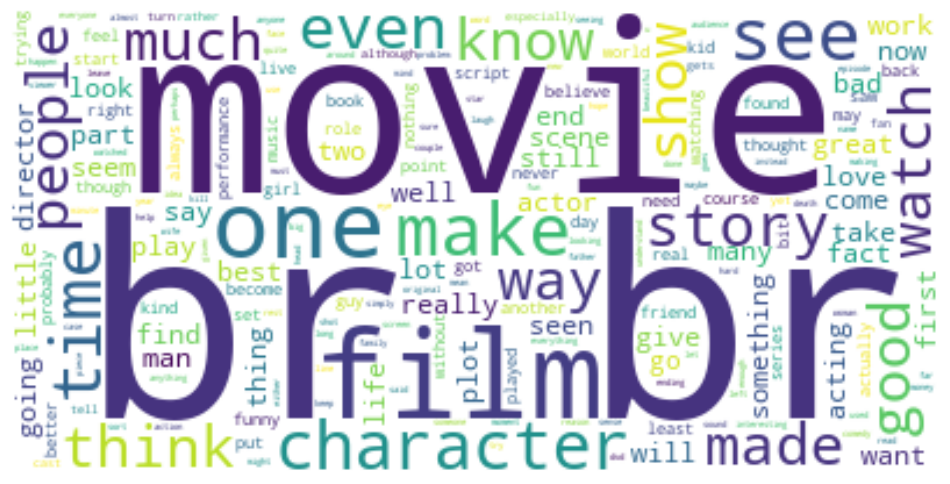

In [ ]:
# Generate a word cloud image
wordcloud = WordCloud(background_color="white").generate(text)

plt.figure(figsize=(12,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


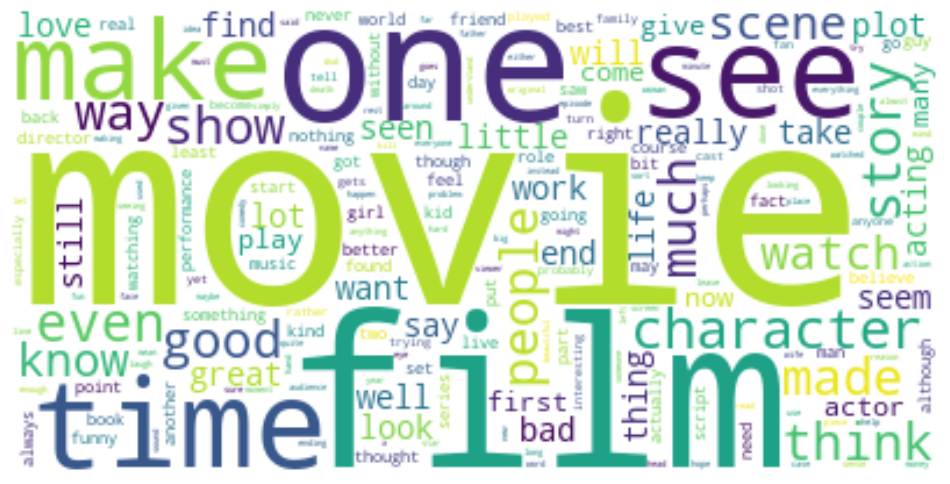

In [29]:
stopwords = set(STOPWORDS)

stopwords.update(["br"])

# Generate a word cloud image
wordcloud = WordCloud(stopwords = stopwords, background_color="white").generate(text)

plt.figure(figsize=(12,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


8.0
6.0


<Axes: ylabel='count'>

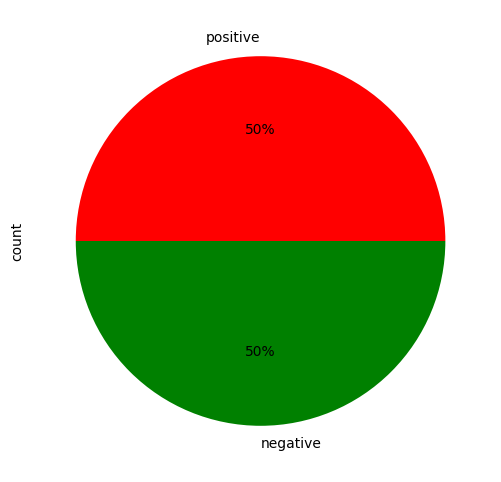

In [30]:
# Plot pie chart showing the sentiment split
plot_size = plt.rcParams["figure.figsize"] 
print(plot_size[0]) 
print(plot_size[1])

plot_size[0] = 8
plot_size[1] = 6
plt.rcParams["figure.figsize"] = plot_size 

imdb_reviews.sentiment_label.value_counts().plot(kind='pie', autopct='%1.0f%%', colors=["red", "green"])

In [ ]:
imdb_reviews.head()

,review,sentiment,sentiment_label
0,? this film was just brilliant casting locatio...,1,positive
1,? big hair big boobs bad music and a giant saf...,0,negative
2,? this has to be one of the worst films of the...,0,negative
3,? the ? ? at storytelling the traditional sort...,1,positive
4,? worst mistake of my life br br i picked this...,0,negative


In [37]:
# Spliting the text and labels
features = imdb_reviews.iloc[:, 0].values
labels = imdb_reviews.iloc[:, 1].values

print(f"features: {features}")
print(f"labels: {labels}")

features: ["? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done d

In [ ]:
# Cleaning up text using regex
processed_features = []

for sentence in range(0, len(features)):
    # Remove HTML tags first (like <br/>, <br>, <p>, etc.)
    processed_feature = re.sub(r'<[^>]+>', '', str(features[sentence]))
    
    # Remove all the special characters
    processed_feature = re.sub(r'\W', ' ', processed_feature)

    # Remove all single characters
    processed_feature= re.sub(r'\s+[a-zA-Z]\s+', ' ', processed_feature)

    # Remove single characters from the start
    processed_feature = re.sub(r'\^[a-zA-Z]\s+', ' ', processed_feature) 

    # Substituting multiple spaces with single space
    processed_feature = re.sub(r'\s+', ' ', processed_feature, flags=re.I)

    # Removing prefixed 'b'
    processed_feature = re.sub(r'^b\s+', '', processed_feature)

    # Converting to Lowercase
    processed_feature = processed_feature.lower()

    processed_features.append(processed_feature)


In [ ]:
features

array(["? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't

In [ ]:
processed_features

[' good ol boy film is almost required to have car chases storyline that has vague resemblance to plot and at least one very pretty country gal with short shorts and low top the pretty gal is here dressed in designer but the redneck stop there jimmy dean is natural as but as tough guy former sheriff he comes up way short big john is big but he isn convincing with the bad part of his bug eyed jack is hoot as always and bo hopkins has been playing this same part for decades ned beatty also does his part in small role but there is no story it more like an episode of in the heat of the night than feature film with easily predictable sentiment perhaps the most glaring problem with this movie is charlie daniels singing the theme you know the one it was made famous by jimmy dean',
 ' good ol boy film is almost required to have car chases storyline that has vague resemblance to plot and at least one very pretty country gal with short shorts and low top the pretty gal is here dressed in designe

In [ ]:
# Performing the vectoriztion using TF-IDF scheme
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# We use max_features of 2500 which is the top 2500 most frequently occuring words to create our bag of words model
# min-df is set to 7 which shows that include words that occur in at least 7 documents. 
# max_df specifies that only use those words that occur in a maximum of 80% of the documents.
vectorizer = TfidfVectorizer(max_features=2500, min_df=7, max_df=0.8, stop_words=stopwords.words('english'))

# We use the vectorizer.fit_transform to transform our words into our processed features vector
processed_features_vec = vectorizer.fit_transform(processed_features).toarray()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nghiatran/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [53]:
# Create training and test ds using a 80%, 20% split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(processed_features_vec, labels, test_size=0.2, random_state=0)

In [54]:
# Rrandom forest algorithm
from sklearn.ensemble import RandomForestClassifier

text_classifier = RandomForestClassifier(n_estimators=200, random_state=0)
text_classifier.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
# Do predictions
predictions = text_classifier.predict(X_test)

In [56]:
# Display the results
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))
print("Accuracy {0:.2f}%".format(100*accuracy_score(y_test, predictions)))

[[4264  729]
 [ 782 4225]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4993
           1       0.85      0.84      0.85      5007

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Accuracy 84.89%


In [57]:
# Obtain a test sample text from the test dataset

for i in range(0,5):
  rand_index = np.random.randint(0,len(processed_features))
  test_sample = processed_features[rand_index]
  print(test_sample)

  # Try the classifer on that text
  vector = vectorizer.transform([test_sample])
  output = text_classifier.predict(vector.toarray())
  print("Sentiment is - " + str(output[0]) + "\n")

 this film was slow but tedious and the acting often into the land of ham character was unappealing as the 60 something woman trying to compete with 20 something for the love of character why is beyond me the title of the movie should have been shallow people on the lake the actors played like they were in rehearsal dreadfully predictable ending to boot can believe this is on this website as comedy
Sentiment is - 0

 one of the many silent comedies stan laurel featured in before he teamed with oliver hardy and is ho hum the story is badly disjointed though this could be because of the modern day edit and the humor itself is not at all inventive br br potential are started and ignored for instance promise to make de sole pay for what she done to him never comes to character doesn seem very centered either but this is common criticism of his work before he developed of laurel hardy fame so it might be that was just expecting to see this br br strongly believe that all the silent films sh

In [58]:
# Using N-grams (unigrams + bigrams) for better feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# Create vectorizer with ngram_range=(1, 2) for unigrams and bigrams
# capture both single words and two-word combinations
vectorizer_ngram = TfidfVectorizer(
    max_features=2500, 
    min_df=1, 
    max_df=0.95, 
    stop_words=stopwords.words('english'),
    ngram_range=(1, 2)  # includes unigrams and bigrams
)

processed_features_vec_ngram = vectorizer_ngram.fit_transform(processed_features).toarray()

print(f"Feature shape with N-grams: {processed_features_vec_ngram.shape}")
print(f"Vocabulary size: {len(vectorizer_ngram.vocabulary_)}")


Feature shape with N-grams: (50000, 2500)
Vocabulary size: 2500


In [59]:
# Split the data for N-gram model (using same split as before)
from sklearn.model_selection import train_test_split

X_train_ngram, X_test_ngram, y_train_ngram, y_test_ngram = train_test_split(
    processed_features_vec_ngram, labels, test_size=0.2, random_state=0
)

print(f"Training set size: {len(X_train_ngram)}")
print(f"Test set size: {len(X_test_ngram)}")


Training set size: 40000
Test set size: 10000


In [60]:
# Random Forest N-gram features
from sklearn.ensemble import RandomForestClassifier

text_classifier_ngram = RandomForestClassifier(n_estimators=200, random_state=0)
text_classifier_ngram.fit(X_train_ngram, y_train_ngram)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Make predictions
predictions_ngram = text_classifier_ngram.predict(X_test_ngram)

# Evaluate N-gram model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_ngram, predictions_ngram))
print("\nClassification Report:")
print(classification_report(y_test_ngram, predictions_ngram))
accuracy_ngram = accuracy_score(y_test_ngram, predictions_ngram)
print(f"\nAccuracy: {accuracy_ngram*100:.2f}%")


Confusion Matrix:
[[4269  724]
 [ 759 4248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4993
           1       0.85      0.85      0.85      5007

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Accuracy: 85.17%


In [62]:
# Compare the two models
import pandas as pd

# Get the original model accuracy
# If you've run the original model earlier, use that accuracy value
# Otherwise, we'll use the value from the results shown: 84.89%
try:
    # Try to use the original accuracy if it was stored
    accuracy_original = accuracy_score(y_test, predictions) * 100
    print("Using accuracy from original model run earlier in notebook")
except:
    # Fallback to the known result
    accuracy_original = 84.89
    print("Using known accuracy value: 84.89%")

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Unigrams Only', 'Unigrams + Bigrams (N-grams)'],
    'Accuracy (%)': [accuracy_original, accuracy_ngram*100],
    'Features': ['Single words only', 'Single words + word pairs'],
    'Feature Count': [2500, 2500]
})

print("="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Calculate improvement
improvement = accuracy_ngram*100 - accuracy_original
print(f"\nImprovement: {improvement:+.2f} percentage points")
if improvement > 0:
    print(f"N-grams model is {improvement:.2f}% better!")
elif improvement < 0:
    print(f"N-grams model is {abs(improvement):.2f}% worse.")
else:
    print("Both models perform the same.")


Using accuracy from original model run earlier in notebook
MODEL COMPARISON
                       Model  Accuracy (%)                  Features  Feature Count
               Unigrams Only         84.89         Single words only           2500
Unigrams + Bigrams (N-grams)         85.17 Single words + word pairs           2500

Improvement: +0.28 percentage points
N-grams model is 0.28% better!
